# Customer Churn Prediction & Revenue Impact Analysis

**Research questions**
1. Which customer segments have the highest observed churn rates?
2. Which features are strongest predictors of churn?
3. Can classification models reliably identify high-risk customers, and how do logistic regression and a tree-based model compare?
4. What is the illustrative revenue at stake among the highest-risk customers?


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, RocCurveDisplay
)

RANDOM_STATE = 42
DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)
df.shape


(7043, 21)

## 1. Data quality and preparation

Preparation is deliberately performed in code so the paper's results can be reproduced.

- Remove `customerID` from predictors because it is an identifier rather than a behavioral feature.
- Encode `Churn` as 1 = Yes and 0 = No.
- Separate numeric and categorical predictors.
- Impute numeric missing values with the median and categorical missing values with the most frequent category inside the modeling pipeline.
- Standardize numeric predictors for logistic regression.
- One-hot encode categorical predictors, with `handle_unknown='ignore'` so unseen categories do not break scoring.
- Check duplicates and missing values before modeling.


In [17]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution:")
print(df["Churn"].value_counts())
print("\nData types:")
display(df.dtypes)


Shape: (7043, 21)

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0

Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Data types:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [18]:
X = df.drop(columns=["Churn", "customerID"])
y = (df["Churn"] == "Yes").astype(int)

categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ]), categorical_features)
])

print("Numeric fields:", numeric_features)
print("Categorical fields:", categorical_features)


Numeric fields: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical fields: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']


## 2. Exploratory segment analysis

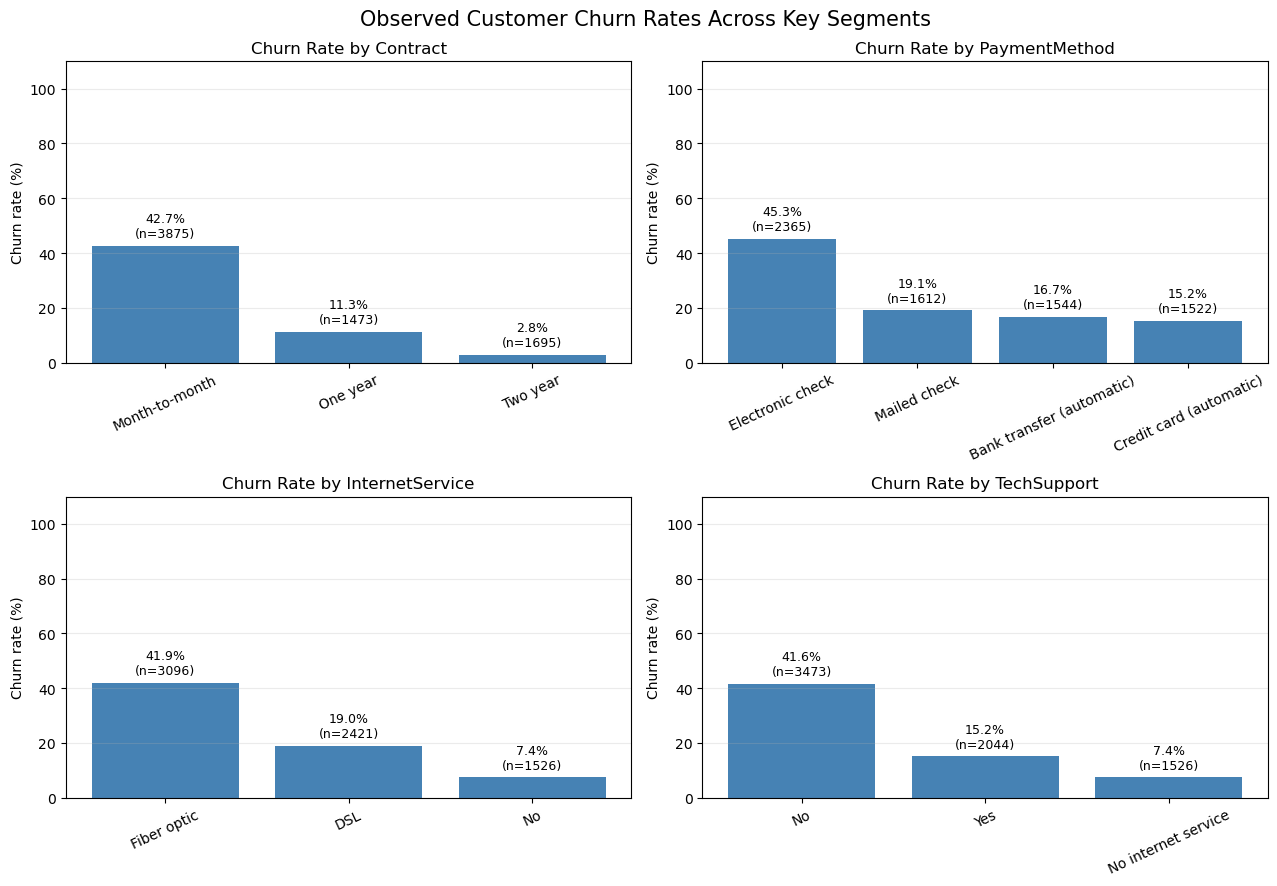

In [19]:
segment_fields = ["Contract", "PaymentMethod", "InternetService", "TechSupport"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for field, ax in zip(segment_fields, axes.flat):
    segment_summary = (
        df.assign(churn_flag=df["Churn"].eq("Yes").astype(int))
        .groupby(field)["churn_flag"]
        .agg(churn_rate="mean", customers="count")
        .sort_values("churn_rate", ascending=False)
    )
    rates_pct = segment_summary["churn_rate"] * 100
    bars = ax.bar(rates_pct.index.astype(str), rates_pct.values, color="steelblue")
    ax.set_title(f"Churn Rate by {field}")
    ax.set_ylabel("Churn rate (%)")
    ax.set_ylim(0, 110)
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.25)

    for bar, rate, count in zip(bars, rates_pct, segment_summary["customers"]):
        ax.annotate(
            f"{rate:.1f}%\n(n={count})",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

fig.suptitle("Observed Customer Churn Rates Across Key Segments", fontsize=15)
fig.tight_layout()
plt.show()


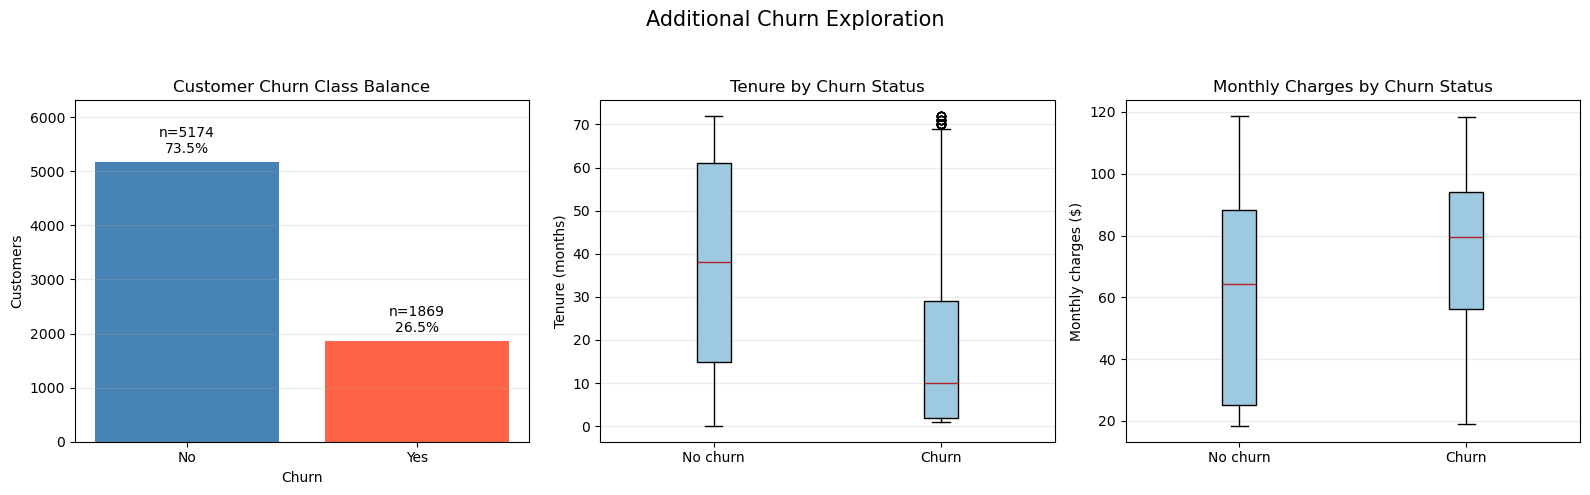

In [20]:
churn_counts = df["Churn"].value_counts().reindex(["No", "Yes"], fill_value=0)
churn_percent = churn_counts / churn_counts.sum() * 100

columns_by_name = {column.casefold(): column for column in df.columns}
tenure_column = columns_by_name["tenure"]
monthly_charges_column = columns_by_name["monthlycharges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bars = axes[0].bar(churn_counts.index, churn_counts.values, color=["steelblue", "tomato"])
axes[0].set_title("Customer Churn Class Balance")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Customers")
axes[0].set_ylim(0, churn_counts.max() * 1.22)
axes[0].grid(axis="y", alpha=0.25)
for bar, count, percent in zip(bars, churn_counts, churn_percent):
    axes[0].annotate(
        f"n={count}\n{percent:.1f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4), textcoords="offset points", ha="center", va="bottom",
    )

for ax, column, title, ylabel in [
    (axes[1], tenure_column, "Tenure by Churn Status", "Tenure (months)"),
    (axes[2], monthly_charges_column, "Monthly Charges by Churn Status", "Monthly charges ($)"),
]:
    groups = [df.loc[df["Churn"] == label, column].dropna() for label in ["No", "Yes"]]
    ax.boxplot(
        groups, tick_labels=["No churn", "Churn"], patch_artist=True,
        boxprops={"facecolor": "#9ecae1"},
        medianprops={"color": "#b22222"},
    )
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Additional Churn Exploration", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


## 3. Modeling approach

Two models are evaluated:

**Logistic regression** provides an interpretable baseline for binary classification and is appropriate when the goal includes understanding how predictors relate to churn risk.

**Random forest** is included as a tree-based alternative because it can capture nonlinear relationships and interactions without requiring those relationships to be specified in advance.

The data is split into 70% training and 30% holdout test data using stratification. Five-fold stratified cross-validation is performed on the training set. Evaluation emphasizes ROC-AUC, precision, recall, F1, and accuracy. Recall is important because missing a true churner can reduce the usefulness of a retention program, while precision matters because unnecessary interventions consume budget and can create poor customer experiences.


In [21]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=500, max_depth=5, class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring=["roc_auc", "accuracy", "precision", "recall", "f1"]
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "CV ROC-AUC": scores["test_roc_auc"].mean(),
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": np.nanmean(scores["test_precision"]),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "Holdout ROC-AUC": roc_auc_score(y_test, prob),
        "Holdout Accuracy": accuracy_score(y_test, pred),
        "Holdout Precision": precision_score(y_test, pred, zero_division=0),
        "Holdout Recall": recall_score(y_test, pred),
        "Holdout F1": f1_score(y_test, pred)
    }

results_df = pd.DataFrame(results).T.round(3)
display(results_df)


/Users/anishsamuel/dsc530/miniconda3/envs/book_env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/anishsamuel/dsc530/miniconda3/envs/book_env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/anishsamuel/dsc530/miniconda3/envs/book_env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/anishsamuel/dsc530/miniconda3/envs/book_env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [15] during transform. These unknown categ

,CV ROC-AUC,CV Accuracy,CV Precision,CV Recall,CV F1,Holdout ROC-AUC,Holdout Accuracy,Holdout Precision,Holdout Recall,Holdout F1
Logistic Regression,0.842,0.765,0.541,0.767,0.634,0.845,0.761,0.534,0.770,0.631
Random Forest,0.825,0.699,0.464,0.853,0.601,0.817,0.685,0.451,0.854,0.590


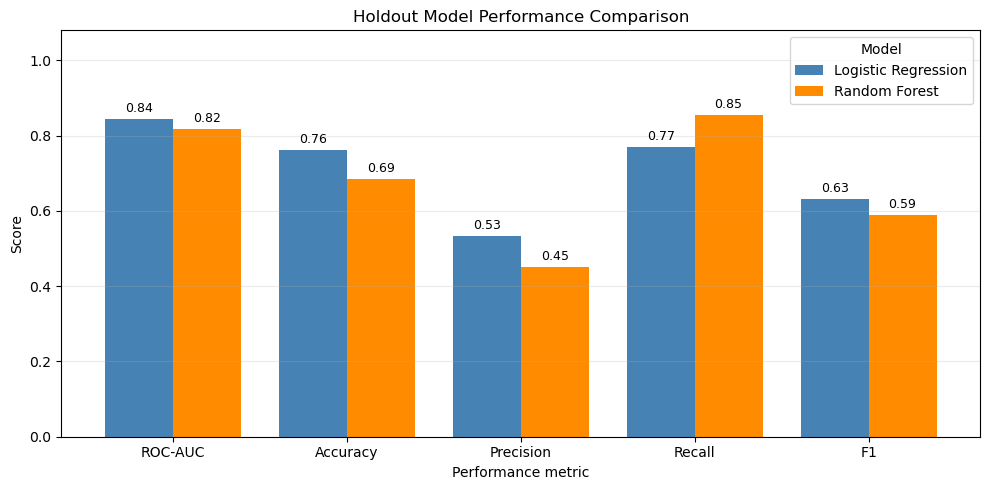

In [22]:
holdout_metrics = results_df[[
    "Holdout ROC-AUC", "Holdout Accuracy", "Holdout Precision",
    "Holdout Recall", "Holdout F1"
]].rename(columns=lambda metric: metric.replace("Holdout ", ""))

ax = holdout_metrics.T.plot(
    kind="bar",
    figsize=(10, 5),
    color=["steelblue", "darkorange"],
    width=0.78,
)
ax.set_title("Holdout Model Performance Comparison")
ax.set_xlabel("Performance metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.08)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Model")
ax.grid(axis="y", alpha=0.25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


/Users/anishsamuel/dsc530/miniconda3/envs/book_env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/anishsamuel/dsc530/miniconda3/envs/book_env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


<Figure size 600x500 with 0 Axes>

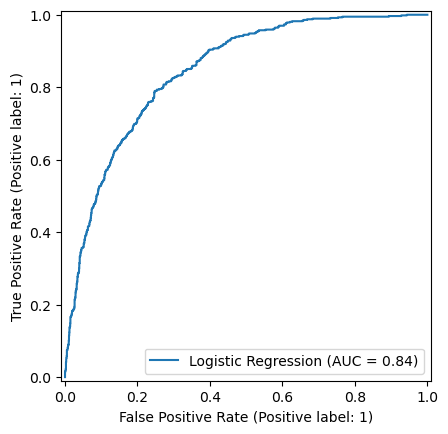

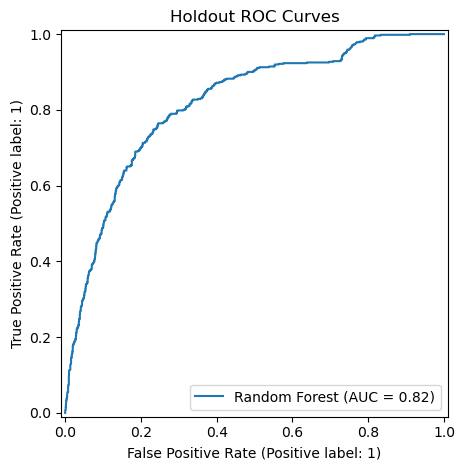

/Users/anishsamuel/dsc530/miniconda3/envs/book_env/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Random Forest confusion matrix:
[[968 584]
 [ 82 479]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.62      0.74      1552
           1       0.45      0.85      0.59       561

    accuracy                           0.68      2113
   macro avg       0.69      0.74      0.67      2113
weighted avg       0.80      0.68      0.70      2113



In [23]:
plt.figure(figsize=(6,5))
for name, model in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, prob, name=name)
plt.title("Holdout ROC Curves")
plt.tight_layout()
plt.show()

rf_pred = models["Random Forest"].predict(X_test)
print("Random Forest confusion matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification report:")
print(classification_report(y_test, rf_pred, zero_division=0))


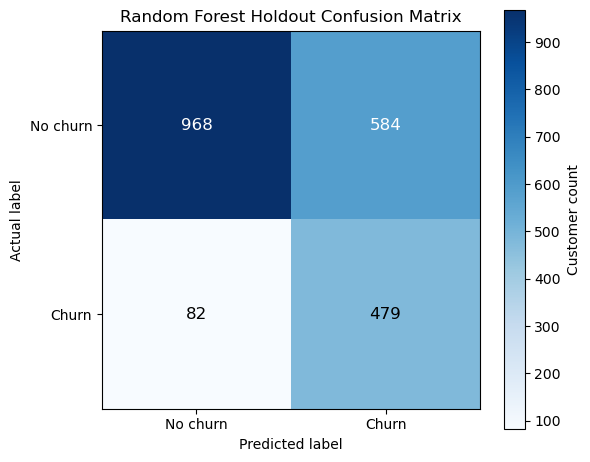

In [24]:
rf_confusion = confusion_matrix(y_test, rf_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(rf_confusion, cmap="Blues")
ax.set_title("Random Forest Holdout Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")
ax.set_xticks([0, 1], labels=["No churn", "Churn"])
ax.set_yticks([0, 1], labels=["No churn", "Churn"])

threshold = rf_confusion.max() / 2
for row in range(rf_confusion.shape[0]):
    for col in range(rf_confusion.shape[1]):
        ax.text(
            col, row, f"{rf_confusion[row, col]:,}",
            ha="center", va="center",
            color="white" if rf_confusion[row, col] > threshold else "black",
            fontsize=12,
        )

fig.colorbar(image, ax=ax, label="Customer count")
fig.tight_layout()
plt.show()


## 4. Interpreting predictors

For logistic regression, coefficients can be inspected after preprocessing. The signs indicate the direction of association in the fitted sample; they should not be interpreted as causal effects. Because this sample is small, coefficient magnitude should be treated as exploratory.

In [25]:
lr = models["Logistic Regression"]
feature_names = lr.named_steps["preprocessor"].get_feature_names_out()
coefs = lr.named_steps["model"].coef_[0]
coef_table = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
coef_table["abs_coefficient"] = coef_table["coefficient"].abs()
display(coef_table.sort_values("abs_coefficient", ascending=False).head(15))


,feature,coefficient,abs_coefficient
102,cat__TotalCharges_1052.35,1.688472,1.688472
171,cat__TotalCharges_1099.6,1.669446,1.669446
3088,cat__TotalCharges_5154.6,1.634926,1.634926
61,cat__TotalCharges_1021.8,1.593016,1.593016
3729,cat__TotalCharges_6579.05,1.590206,1.590206
2707,cat__TotalCharges_4481,1.575262,1.575262
445,cat__TotalCharges_1327.15,1.574953,1.574953
2899,cat__TotalCharges_4820.15,1.563340,1.563340
1484,cat__TotalCharges_2460.15,1.517053,1.517053
2174,cat__TotalCharges_3563.8,1.514970,1.514970


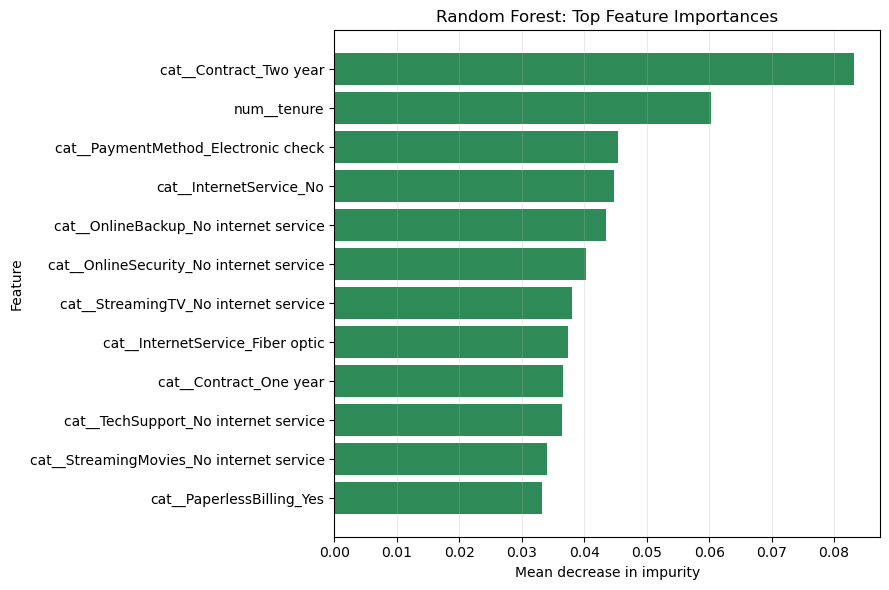

In [26]:
rf_model = models["Random Forest"]
# Refit on the training partition so the transformed feature names align with this model.
rf_model.fit(X_train, y_train)
rf_feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
rf_importances = rf_model.named_steps["model"].feature_importances_
importance_table = (
    pd.DataFrame({"feature": rf_feature_names, "importance": rf_importances})
    .nlargest(12, "importance")
    .sort_values("importance")
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance_table["feature"], importance_table["importance"], color="seagreen")
ax.set_title("Random Forest: Top Feature Importances")
ax.set_xlabel("Mean decrease in impurity")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()


## 5. Illustrative revenue-impact analysis

A simple scenario translates model scores into a business measure. The logistic model is refit to all available rows, customers are ranked by predicted churn probability, and the top 20% are treated as the hypothetical retention target.

This is **not** a causal estimate. For illustration only, assume:
- a retention offer prevents 30% of churn among the targeted customers who would otherwise leave;
- annual revenue at stake is approximated as monthly charge × 12;
- the intervention costs $50 per targeted customer.

The assumptions can be changed below.


In [27]:
full_lr = models["Logistic Regression"].fit(X, y)
analysis = df.copy()
analysis["risk_score"] = full_lr.predict_proba(X)[:, 1]

target_fraction = 0.20
retention_effect = 0.30
offer_cost = 50

target_n = int(np.ceil(len(analysis) * target_fraction))
target = analysis.nlargest(target_n, "risk_score")
observed_churners = target[target["Churn"] == "Yes"]

revenue_at_stake = observed_churners["MonthlyCharges"].sum() * 12
estimated_saved_revenue = revenue_at_stake * retention_effect
intervention_cost = target_n * offer_cost
estimated_net_value = estimated_saved_revenue - intervention_cost

print("Target customers:", target_n)
print("Observed churners in target:", len(observed_churners))
print("Illustrative annual revenue at stake: $", round(revenue_at_stake, 2))
print("Illustrative revenue retained at 30% effect: $", round(estimated_saved_revenue, 2))
print("Illustrative intervention cost: $", round(intervention_cost, 2))
print("Illustrative net value: $", round(estimated_net_value, 2))
display(target[["customerID", "risk_score", "MonthlyCharges", "Churn"]])


Target customers: 1409
Observed churners in target: 1203
Illustrative annual revenue at stake: $ 1151346.6
Illustrative revenue retained at 30% effect: $ 345403.98
Illustrative intervention cost: $ 70450
Illustrative net value: $ 274953.98


,customerID,risk_score,MonthlyCharges,Churn
4624,0325-XBFAC,0.971190,94.70,Yes
3467,8414-MYSHR,0.951193,91.40,Yes
4800,9300-AGZNL,0.946044,94.00,Yes
1410,7024-OHCCK,0.944802,93.85,Yes
3380,5178-LMXOP,0.944648,95.10,Yes
...,...,...,...,...
1563,3223-DWFIO,0.726486,69.35,No
4790,5216-WASFJ,0.726458,84.85,No
3978,0432-CAJZV,0.726210,90.70,No
4381,7481-ATQQS,0.726056,90.85,Yes
